<a href="https://colab.research.google.com/github/MehrabHussain47/Python-Self-Practice/blob/master/Class_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization Part Two

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [ ]:
x = [1, 2, 3, 4, 10]
y = [5, 4, 3, 2, 1]

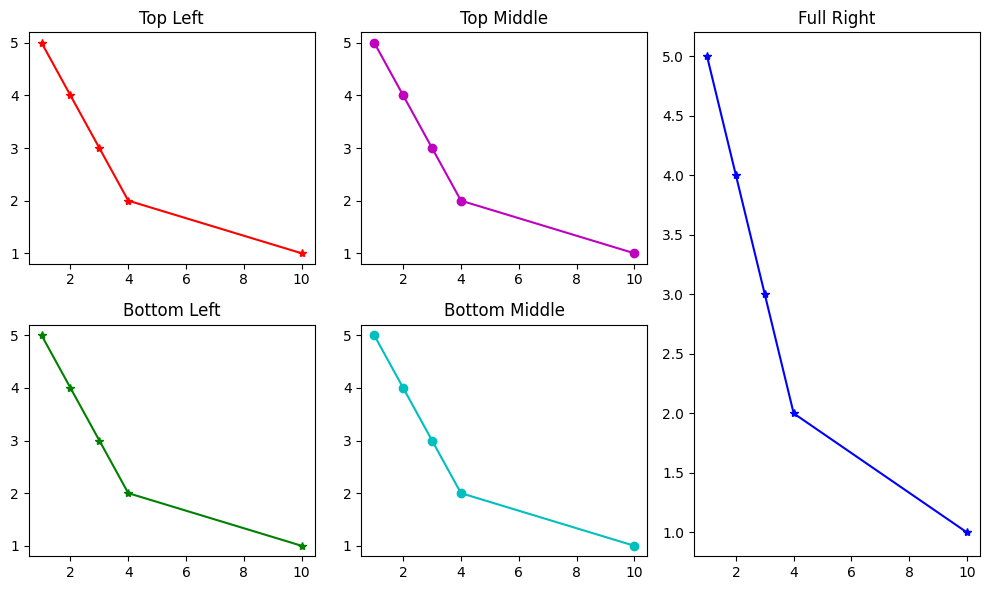

In [ ]:
fig = plt.figure(figsize=(10, 6))

gs = gridspec.GridSpec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, y , 'r-*')
ax1.set_title("Top Left")

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, y , 'g-*')
ax2.set_title("Bottom Left")

ax3 = fig.add_subplot(gs[0, 1])
ax3.plot(x, y , 'm-o')
ax3.set_title("Top Middle")

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(x, y , 'c-o')
ax4.set_title("Bottom Middle")

ax5 = fig.add_subplot(gs[:, 2])
ax5.plot(x, y , 'b-*')
ax5.set_title("Full Right")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Time Series data.csv to Time Series data.csv


In [ ]:
df = pd.read_csv('Time Series data.csv')

In [ ]:
df.head()

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts
0,25.661274,591.163282,5.0
1,26.560024,657.393558,3.0
2,28.596623,779.978584,4.0
3,28.104512,726.827852,5.0
4,29.889647,775.217459,5.0


In [ ]:
df.shape

(120, 3)

In [ ]:
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

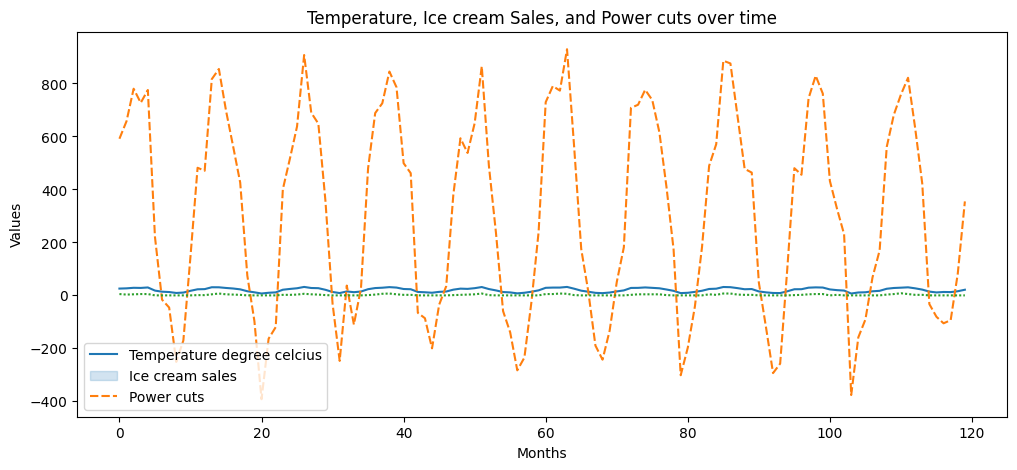

In [ ]:
# Lineplot
plt.figure(figsize=(12,5))
sns.lineplot(data=df[['Avg_Temperature', 'Ice_Cream_Sales', 'Power_Cuts']])
plt.title('Temperature, Ice cream Sales, and Power cuts over time')
plt.xlabel('Months')
plt.ylabel('Values')
plt.legend(['Temperature degree celcius', 'Ice cream sales', 'Power cuts'])
plt.show()

In [ ]:
df['Temp_MA_6'] = df['Avg_Temperature'].rolling(window=6).mean() # Moving average of 6 months of Average Temperature er mean
df['IceCream_Sales_MA_6'] = df['Ice_Cream_Sales'].rolling(window=6).mean()

In [ ]:
df.head() # In 6th row it won't show NaN

,Avg_Temperature,Ice_Cream_Sales,Power_Cuts,Temp_MA_6,IceCream_Sales_MA_6,Temp_MA_3,IceCream_Sales_MA_3
0,25.661274,591.163282,5.0,NaN,NaN,NaN,NaN
1,26.560024,657.393558,3.0,NaN,NaN,NaN,NaN
2,28.596623,779.978584,4.0,NaN,NaN,26.939307,676.178474
3,28.104512,726.827852,5.0,NaN,NaN,27.753719,721.399998
4,29.889647,775.217459,5.0,NaN,NaN,28.863594,760.674632


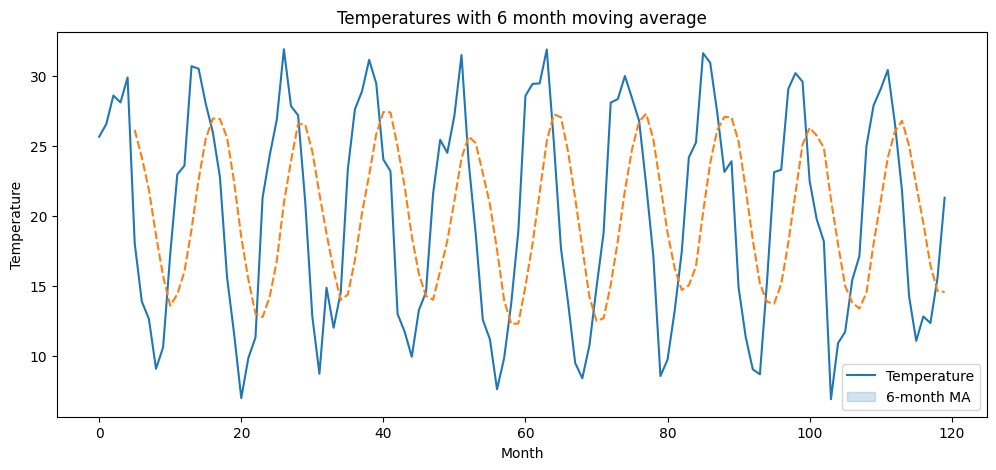

In [ ]:
# Moving Average
plt.figure(figsize=(12,5))
sns.lineplot(data=df[['Avg_Temperature', 'Temp_MA_6']])
plt.title('Temperatures with 6 month moving average')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.legend(['Temperature', '6-month MA'])
plt.show()

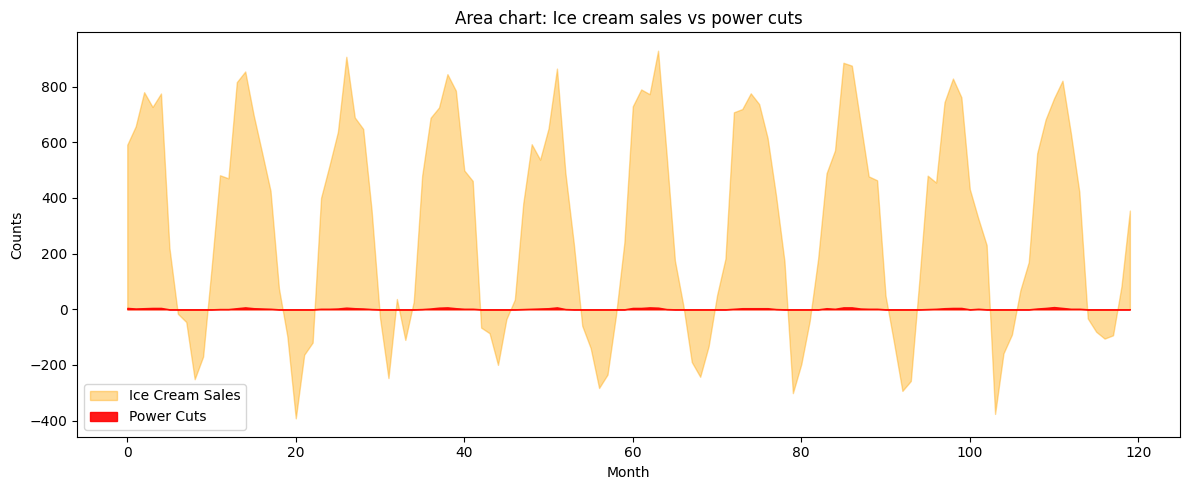

In [ ]:
# Area Chart
plt.figure(figsize=(12,5))
plt.fill_between(df.index, df['Ice_Cream_Sales'], alpha=0.4, label='Ice Cream Sales', color='orange')
plt.fill_between(df.index, df['Power_Cuts'], alpha=0.9, label='Power Cuts', color='red')
plt.title('Area chart: Ice cream sales vs power cuts')
plt.xlabel('Month')
plt.ylabel('Counts')
plt.legend()
plt.tight_layout()
plt.show()

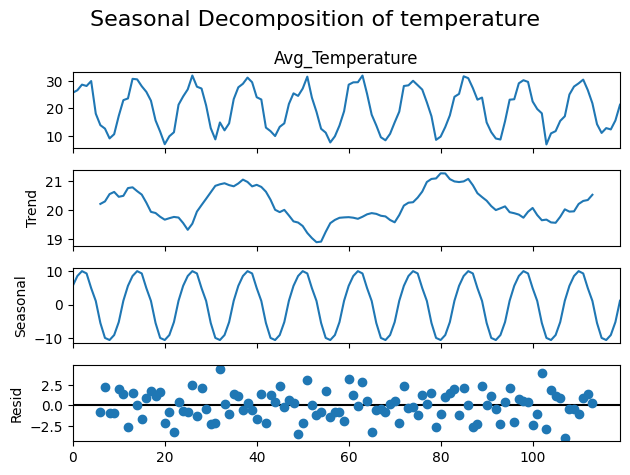

In [ ]:
# Seasonal Decomposition
result = seasonal_decompose(df['Avg_Temperature'], model='additive', period=12)
result.plot()
plt.suptitle("Seasonal Decomposition of temperature", fontsize=16)
plt.tight_layout()
plt.show()